# Load and explore data

In [27]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
housing = fetch_california_housing(as_frame=True)

In [28]:
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [29]:
data = df[["MedInc","MedHouseVal"]]
data.describe()

,MedInc,MedHouseVal
count,20640.000000,20640.000000
mean,3.870671,2.068558
std,1.899822,1.153956
min,0.499900,0.149990
25%,2.563400,1.196000
50%,3.534800,1.797000
75%,4.743250,2.647250
max,15.000100,5.000010


<Axes: xlabel='MedInc', ylabel='MedHouseVal'>

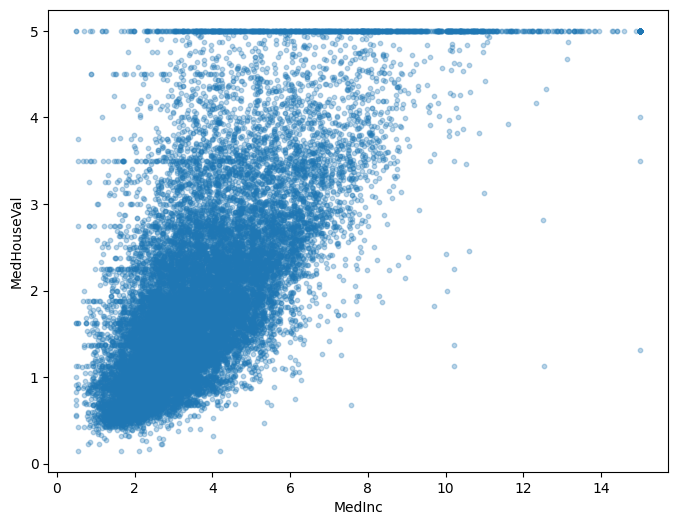

In [30]:
data.plot(kind="scatter", x="MedInc", y="MedHouseVal", alpha=0.3, s=10, figsize=(8,6))

## Observations from the raw scatter plot

- **Cap at MedHouseVal = 5.0**: There's a dense horizontal line of points sitting exactly 
  at y = 5.0. This isn't a natural data pattern — the dataset caps median house value at 
  $500,000, so any district actually worth more than that gets clipped down to exactly 5.0. 
  This means the true relationship for high-value districts is hidden, and it could pull 
  my regression line in a way that doesn't reflect reality at the high end.

- **Dense cluster, x: 0–8, y: 0–4.5**: The majority of the data sits in a cluster of low-to-mid 
  income (roughly 0–8) paired with low-to-mid house values (roughly 0–4.5). Above that, points 
  get sparser and more spread out, suggesting few districts have very high income. This looks 
  like a right-skewed distribution rather than an even spread across the income range.

- **Implication for modeling**: Since most of my data is concentrated in a lower range, a small 
  number of high-income outliers could have outsized influence on my learned slope/intercept 
  once I start training.

## Linear Regression Equation
Given: ŷ = w·x + b
- ŷ is what we are trying to predict which is the Median House Value, while x is the Median Income
- w is our slope which tells us how much ŷ changes for every 1 unit increase in x
- b is our bias which tells us what would the model predict if the median income was 0?

# Preprocessing

In [31]:
from sklearn.model_selection import train_test_split
X = df["MedInc"]
y = df["MedHouseVal"]
trainX, valX, trainY, valY = train_test_split(X,y, test_size=0.25, random_state=8)
print(trainX.shape, valX.shape, trainY.shape, valY.shape)

(15480,) (5160,) (15480,) (5160,)


# Implementing loss functions manually

In [32]:
import numpy as np
dummy_true = np.array([3, 5, 2, 10])
dummy_pred = np.array([2.5, 5.5, 1, 2])
def mse(y_true,y_pred):
    return np.mean((y_true - y_pred) ** 2)
def mae(y_true,y_pred):
    return np.mean(np.abs(y_true - y_pred))
def rmse(y_true,y_pred):
    return np.sqrt(mse(y_true,y_pred))

print("MAE:", mae(dummy_true, dummy_pred))
print("MSE:", mse(dummy_true, dummy_pred))
print("RMSE:", rmse(dummy_true, dummy_pred))

MAE: 2.5
MSE: 16.375
RMSE: 4.046603514059662


# Implement and derive gradients

## Gradients

Starting from MSE = (1/n) * Σ (y - ŷ)², where ŷ = w·x + b

**Gradient with respect to w:**
∂MSE/∂w = -(2/n) * Σ (y - ŷ) · x

**Gradient with respect to b:**
∂MSE/∂b = -(2/n) * Σ (y - ŷ)

These tell us the direction and magnitude to adjust w and b to reduce loss.
In gradient descent, we update:
w = w - learning_rate * ∂MSE/∂w
b = b - learning_rate * ∂MSE/∂b

In [33]:
def compute_gradients(x, y, w, b):
    y_pred = (w*x) + b
    error = y - y_pred
    dw = -2 * np.mean(error*x)        # -(2/n) * sum(error * x)
    db =  -2 * np.mean(error)         # -(2/n) * sum(error)
    return dw, db

x_test = np.array([1, 2, 3])
y_test = np.array([3, 5, 7])

dw, db = compute_gradients(x_test, y_test, w=0, b=0)
print("dw:", dw, "db:", db)

dw: -22.666666666666668 db: -10.0


# Mini-batch SGD training loop

In [56]:
# Set up parameters
w = 0.0
b = 0.0

# Hyperparameters
learning_rate = 0.1
epochs = 50
batch_size = 30

# Track loss
loss_list = []

In [35]:
# shuffle
indices = np.arange(len(trainX))
np.random.shuffle(indices)
X_shuffled = trainX.to_numpy()[indices]
Y_shuffled = trainY.to_numpy()[indices]
print("Original trainX (first 5):", trainX.to_numpy()[:5])
print("Shuffled X_shuffled (first 5):", X_shuffled[:5])

sample_x = trainX.to_numpy()[0]
sample_y = trainY.to_numpy()[0]
print("\nOriginal pair:", sample_x, "->", sample_y)

match_index = np.where(X_shuffled == sample_x)[0][0]
print("Found in shuffled data at position", match_index, "with y =", Y_shuffled[match_index])

Original trainX (first 5): [3.6471 3.4896 4.7515 2.8326 5.8993]
Shuffled X_shuffled (first 5): [3.9783 3.0587 1.625  3.0313 2.1417]

Original pair: 3.6471 -> 1.014
Found in shuffled data at position 79 with y = 1.014


In [36]:
for start in range(0,len(X_shuffled),batch_size):
    end = start + batch_size
    X_batch = X_shuffled[start:end]
    y_batch = Y_shuffled[start:end]
    if start < 90:
        print("\nBatch from index", start, "to", end)
        print("X_batch:", X_batch)
        print("y_batch:", y_batch)


Batch from index 0 to 30
X_batch: [ 3.9783  3.0587  1.625   3.0313  2.1417  2.6929  1.9718  4.5461  2.4412
  2.      2.5477  2.6042  5.1165  3.0431 10.2317  3.968   3.017   5.6228
  2.4464  3.0446  3.7794  2.9154  2.9417  3.8125  3.3565  4.5536  3.6897
  2.3654  1.9241  4.05  ]
y_batch: [3.741   1.431   0.5     0.8     1.222   1.193   0.698   2.424   0.616
 1.75    0.83    2.875   1.842   2.629   5.00001 1.021   1.125   3.754
 0.725   1.019   1.946   2.033   1.78    2.351   3.864   1.901   1.011
 1.375   1.5     4.231  ]

Batch from index 30 to 60
X_batch: [3.0466 3.37   4.7159 3.8047 4.4033 1.925  4.2121 1.8463 4.163  3.0938
 6.3223 2.9632 3.1574 2.8306 3.0963 5.4889 3.8317 4.6806 3.5322 3.2377
 3.7426 2.5068 1.8446 2.2917 2.7794 1.6983 5.2374 2.4167 4.8623 3.9745]
y_batch: [1.596 3.303 3.659 2.047 2.676 3.    1.281 0.726 1.125 1.894 2.232 2.863
 0.892 0.875 1.569 2.323 2.375 2.889 3.619 1.841 1.355 1.563 0.857 1.451
 3.5   0.726 1.855 0.67  1.769 1.708]

Batch from index 60 to 90
X_

In [42]:
for epoch in range(epochs):
    indices = np.arange(len(trainX))
    np.random.shuffle(indices)
    X_shuffled = trainX.to_numpy()[indices]
    y_shuffled = trainY.to_numpy()[indices]

    for start in range(0,len(X_shuffled),batch_size):
        end = start + batch_size
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]
        dw, db = compute_gradients(X_batch,y_batch,w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db

    train_preds = (w* trainX) + b

    epoch_loss = mse(trainY,train_preds)
    loss_list.append(epoch_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {epoch_loss}")

Epoch 0, Loss: 0.7088216733760656
Epoch 10, Loss: 0.7009916630841598
Epoch 20, Loss: 0.7092598647380751
Epoch 30, Loss: 0.7008186597734998
Epoch 40, Loss: 0.7098428161282226


In [43]:
mean = np.mean(trainX)
std = np.std(trainX)
trainX_scaled = ((trainX - mean)/std)
valX_scaled = ((valX - mean)/std)
print("Train mean:", trainX_scaled.mean(), "Train std:", trainX_scaled.std())
print("Val mean:", valX_scaled.mean(), "Val std:", valX_scaled.std())

Train mean: -2.3868360632768225e-16 Train std: 1.0000323013065961
Val mean: -0.016949257052202665 Val std: 0.9649947850638111


Epoch 0, Loss: 0.7044186552202655
Epoch 10, Loss: 0.7145357491981231
Epoch 20, Loss: 0.7072049311910402
Epoch 30, Loss: 0.7034904547828538
Epoch 40, Loss: 0.7204166972979597


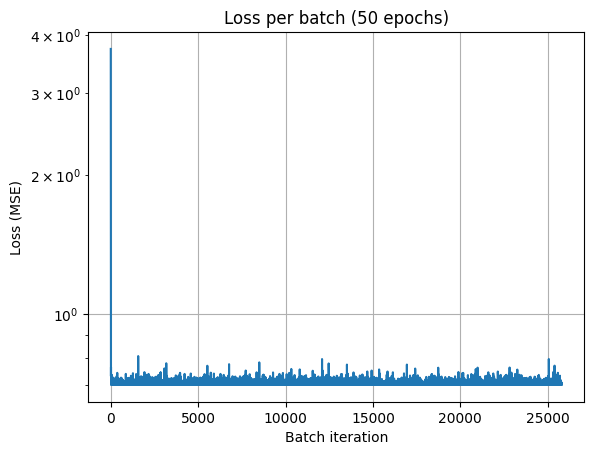

Final w: 0.8206487473517966
Final b: 2.113370970476296


In [66]:
w = 0.0
b = 0.0
loss_list = []   # this will now store loss per BATCH, not per epoch

for epoch in range(epochs):
    indices = np.arange(len(trainX))
    np.random.shuffle(indices)
    X_shuffled = trainX_scaled.to_numpy()[indices]
    y_shuffled = trainY.to_numpy()[indices]

    for start in range(0, len(X_shuffled), batch_size):
        end = start + batch_size
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]
        dw, db = compute_gradients(X_batch, y_batch, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # compute and store loss after EVERY batch, not just per epoch
        train_preds = (w * trainX_scaled) + b
        batch_loss = mse(trainY, train_preds)
        loss_list.append(batch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {batch_loss}")

import matplotlib.pyplot as plt
plt.plot(loss_list)
plt.xlabel("Batch iteration")
plt.ylabel("Loss (MSE)")
plt.title("Loss per batch (50 epochs)")
plt.yscale('log')
plt.grid(True)
plt.show()

print("Final w:", w)
print("Final b:", b)

## Analysis
After tuning hyperparameters, we settled on learning_rate = 0.1, batch_size = 30, 
tracking loss after every batch (not just every epoch) to see the fine-grained convergence behavior.

The graph shows a sharp drop in loss within the first several batches, followed by a long, 
relatively flat region for the rest of training. This shows the model converges almost immediately. Because MedInc is only loosely related to MedHouseVal (lots of noise/scatter in the data), there's a "floor" to how low the loss can go with just one feature. Once the model reaches that floor, further batches only produce small fluctuations around it rather than continued improvement.

We used a log scale on the y-axis because the initial drop (from ~4 down to ~0.7) is so much 
larger than the later fluctuations (within ~0.7-0.75) that a normal linear scale would make the 
flat region look almost invisible by comparison.

lr=0.001: 50 epochs recorded, final loss = 0.7007387296294071
lr=0.01: 50 epochs recorded, final loss = 0.7008092904736731
lr=0.1: 50 epochs recorded, final loss = 0.7015435820339555
lr=0.5: 50 epochs recorded, final loss = 0.7130969549935473
lr=1: 50 epochs recorded, final loss = 36571761179.64189


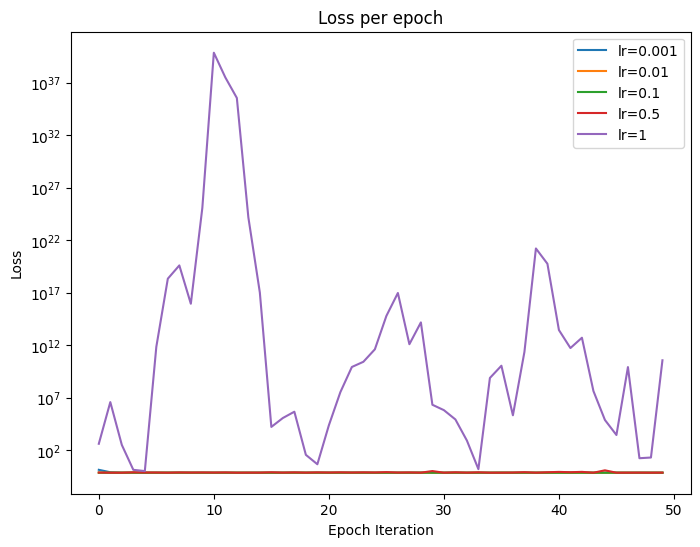

In [69]:
learning_rates_to_test = [0.001, 0.01, 0.1, 0.5, 1]
all_loss_curves = {}

for lr in learning_rates_to_test:
    w = 0.0
    b = 0.0
    loss_list = []

    for epoch in range(epochs):
        indices = np.arange(len(trainX))
        np.random.shuffle(indices)
        X_shuffled = trainX_scaled.to_numpy()[indices]
        y_shuffled = trainY.to_numpy()[indices]

        for start in range(0, len(X_shuffled), batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            dw, db = compute_gradients(X_batch, y_batch, w, b)
            w = w - lr * dw
            b = b - lr * db

        train_preds = (w * trainX_scaled) + b
        epoch_loss = mse(trainY, train_preds)
        loss_list.append(epoch_loss)
    all_loss_curves[lr] = loss_list

for lr, losses in all_loss_curves.items():
    print(f"lr={lr}: {len(losses)} epochs recorded, final loss = {losses[-1]}")

plt.figure(figsize=(8,6))
for lr, losses in all_loss_curves.items():
    plt.plot(losses, label=f"lr={lr}")
plt.xlabel("Epoch Iteration")
plt.ylabel("Loss")
plt.yscale('log')
plt.legend()
plt.title("Loss per epoch")
plt.show()

## Analysis
All learning rates except lr=1 converge almost instantly, settling into a relatively flat 
line near the ~0.70 loss floor. lr=0.5 is slightly worse (final loss ~0.88), but still stable
and converged — it just lands in a slightly worse spot than the smaller rates.

lr=1 is unstable and diverges: instead of settling, its loss explodes and fluctuates wildly, 
reaching values as extreme as 10^37, then partially recovering before spiking again. This never 
stabilizes.

A learning rate that's too small (e.g., 0.001) makes very small, cautious updates each step — 
safe but slow to converge if the floor were farther away. A learning rate that's too large 
(e.g., lr=1) causes updates that overshoot the minimum so badly that the model's parameters 
spiral out of control instead of converging. The "best" learning rate balances these: large 
enough to converge quickly, small enough to stay stable.

Because lr=1's values are so extreme, this log-scale plot makes it hard to distinguish 
differences among the stable learning rates (0.001–0.5). A second plot, excluding lr=1 and 
using a normal linear scale, would better show those finer differences.

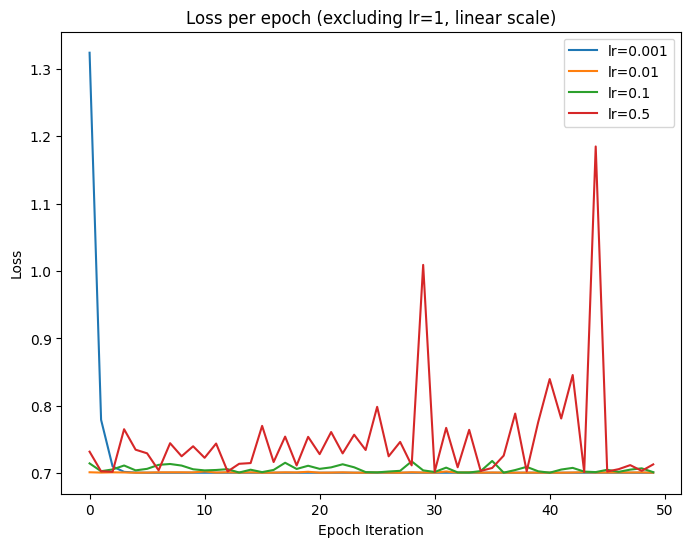

In [70]:
plt.figure(figsize=(8,6))
for lr, losses in all_loss_curves.items():
    if lr == 1:
        continue
    plt.plot(losses, label=f"lr={lr}")
plt.xlabel("Epoch Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss per epoch (excluding lr=1, linear scale)")
plt.show()

## Analysis (excluding lr=1)
With lr=1 removed and the plot on a linear scale, we can see more detail among the remaining 
learning rates. lr=0.5 is noisy/unstable, spiking as high as ~1.2 at times, but it's still 
roughly converged around the 0.7 floor — unlike lr=1, which never recovers and diverges to 
astronomical values.

lr=0.001 starts around 1.3 and drops down to the floor over the first couple epochs, making it 
one of the slower learning rates we tested, even though it's still fast in absolute terms. 
lr=0.01 is nearly perfectly flat — the most stable of the four. lr=0.1 shows a small amount of 
noise but stays close to the floor throughout.

Overall, smaller learning rates converge more slowly but more smoothly; larger learning rates 
converge faster (or not at all, in lr=1's case) but with more risk of instability or divergence. 
The best choice balances speed and stability which in this case, lr=0.01 or lr=0.1 both look like strong picks.